<a href="https://colab.research.google.com/github/YaswanthAgraharapu/Emergency-Vechicle-Detectoin-in-Traffic/blob/main/GNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!nvidia-smi

Thu Mar 12 16:27:09 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip uninstall ultralytics -y
!pip install ultralytics --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 48.6 MB/s eta 0:00:00


In [ ]:
import torch

print("GPU Available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0))

GPU Available: True
GPU Name: Tesla T4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

data_yaml_dir = "/content/drive/MyDrive/emergency yolov8"
os.makedirs(data_yaml_dir, exist_ok=True)

data_yaml_path = os.path.join(data_yaml_dir, "data.yaml")

with open(data_yaml_path, "w") as f:
    f.write("""
train: /content/drive/MyDrive/emergency yolov8/train/images
val: /content/drive/MyDrive/emergency yolov8/valid/images
test: /content/drive/MyDrive/emergency yolov8/test/images

nc: 3
names: ['Ambulance', 'fire truck', 'police']
""")

print("data.yaml created")

data.yaml created


In [ ]:
import torch
!pip install ultralytics --upgrade
from ultralytics import YOLO

model = YOLO("yolov8m.pt")

model.train(
    data="/content/drive/MyDrive/emergency yolov8/data.yaml",
    epochs=120,
    imgsz=640,
    batch=8,
    device=0,   # use GPU
    name="emergency_3class_fixed"
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 64.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/emergency yolov8/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=120, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchs

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a690c0bf6b0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [ ]:
metrics = model.val()

print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,841,497 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 4.3±8.7 ms, read: 30.4±22.1 MB/s, size: 73.3 KB)
val: Scanning /content/drive/MyDrive/emergency yolov8/valid/labels.cache... 129 images, 9 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 138/138 52.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 1.6it/s 5.7s
                   all        138        144       0.87      0.922      0.931      0.771
             Ambulance         49         54      0.879      0.981      0.923      0.825
            fire truck         41         45      0.894      0.867       0.92      0.704
                police         39         45      0.838      0.918      0.949      0.784
Speed: 5.6ms preprocess, 21.7ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to /content/runs/dete

In [ ]:
!pip install transformers timm torchvision

In [ ]:
import os
from PIL import Image

test_folder="/content/drive/MyDrive/emergency yolov8/test/images"

image_path=os.listdir(test_folder)[0]

image=Image.open(os.path.join(test_folder,image_path))

In [ ]:
import os
from PIL import Image

test_folder="/content/drive/MyDrive/emergency yolov8/test/images"

image_path=os.listdir(test_folder)[0]

image=Image.open(os.path.join(test_folder,image_path))

In [ ]:
from transformers import DetrImageProcessor, DetrForObjectDetection
from PIL import Image
import torch
import os

processor = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50")
transformer_model = DetrForObjectDetection.from_pretrained("facebook/detr-resnet-50")

# Using the variables from the previous cell to correctly locate an image
# test_folder and image_path are already defined in the notebook state
image_full_path = os.path.join(test_folder, image_path)
image = Image.open(image_full_path)

inputs = processor(images=image, return_tensors="pt")

outputs = transformer_model(**inputs)

print(outputs)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2586: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  module._load_from_state_dict(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/batchnorm.py:133: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  super()._load_from_state_dict(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/batchnorm.py:133: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, whi

Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                                         | Status     |  | 
----------------------------------------------------------------------------+------------+--+-
model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DetrObjectDetectionOutput(loss=None, loss_dict=None, logits=tensor([[[-15.2736,   1.9888,  -1.6499,  ..., -10.2236,  -8.9460,   8.4265],
         [-16.5981,   5.8759,  -3.1195,  ...,  -8.2890,  -7.3768,   9.6721],
         [-14.5326,   4.2390,  -0.3391,  ..., -11.3808,  -8.6231,   8.3158],
         ...,
         [-15.6554,   0.1418,  -1.2069,  ...,  -4.1760,  -6.6463,   8.4966],
         [-15.8281,   0.8524,  -1.7199,  ...,  -9.2978,  -7.5144,   9.5474],
         [-15.9624,   0.8875,  -0.7165,  ...,  -5.4989,  -7.0079,   8.8423]]], grad_fn=<ViewBackward0>), pred_boxes=tensor([[[3.2378e-03, 5.3415e-01, 6.4802e-03, 1.1714e-01],
         [2.9477e-01, 4.6122e-01, 3.6117e-02, 9.2878e-02],
         [9.9352e-01, 4.8128e-01, 1.2994e-02, 2.8733e-01],
         [8.9104e-01, 3.2457e-01, 4.7770e-02, 8.1780e-02],
         [2.7496e-01, 4.5783e-01, 6.2973e-02, 1.2997e-01],
         [4.9225e-01, 4.9147e-01, 8.6960e-01, 4.9189e-01],
         [3.0161e-01, 4.6924e-01, 2.5872e-02, 8.5705e-02],
         [2.

In [ ]:
!cp /content/runs/detect/emergency_3class_fixed/weights/best.pt \
/content/drive/MyDrive/emergency_best.pt

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/emergency_best.pt")

In [ ]:
model = YOLO("/content/drive/MyDrive/emergency_best.pt")

results = model.predict(
    source="/content/drive/MyDrive/emergency yolov8/test/images",
    conf=0.25,
    save=True
)


image 1/65 /content/drive/MyDrive/emergency yolov8/test/images/-2024-03-12-010255_png.rf.936b5115400725c0cb3102de32aabfa1.jpg: 640x640 1 police, 40.3ms
image 2/65 /content/drive/MyDrive/emergency yolov8/test/images/-2024-03-13-002432_png.rf.7f2977a101b843113f2a174b83b28244.jpg: 640x640 1 police, 38.1ms
image 3/65 /content/drive/MyDrive/emergency yolov8/test/images/-2024-03-13-004215_png.rf.146d4c327f6aa7c4568abf6361a2dec3.jpg: 640x640 2 polices, 38.7ms
image 4/65 /content/drive/MyDrive/emergency yolov8/test/images/-2024-04-24-005808_png.rf.8e7fc377fc9eb9f1e430fbeab7e1e940.jpg: 640x640 1 police, 37.9ms
image 5/65 /content/drive/MyDrive/emergency yolov8/test/images/-2024-04-24-005843_png.rf.ed2cf50f61c6d55944f64985ec5ed156.jpg: 640x640 1 police, 37.9ms
image 6/65 /content/drive/MyDrive/emergency yolov8/test/images/-2024-04-24-010809_png.rf.ebd1e95bafb5080a3149af46bc6c2ff6.jpg: 640x640 1 police, 33.5ms
image 7/65 /content/drive/MyDrive/emergency yolov8/test/images/-2024-04-24-010947_png.

In [ ]:
import pandas as pd

detections=[]

for r in results:
    boxes=r.boxes.xyxy.cpu().numpy()
    classes=r.boxes.cls.cpu().numpy()
    scores=r.boxes.conf.cpu().numpy()

    for box,cls,score in zip(boxes,classes,scores):
      detections.append({
          "x":box[0],
          "y":box[1],
          "confidence":score,
          "class":int(cls)
          })

df=pd.DataFrame(detections)

df.to_csv("/content/drive/MyDrive/detections.csv",index=False)

In [ ]:
!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 76.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import torch
import numpy as np
from torch_geometric.data import Data

df=pd.read_csv("/content/drive/MyDrive/detections.csv")

coords = df[["x","y"]].values

edges = []
threshold = 200

for i in range(len(coords)):
    for j in range(len(coords)):
        if i != j:
            dist = np.linalg.norm(coords[i] - coords[j])
            if dist < threshold:
                edges.append([i, j])

# Edge case fix
if len(edges) == 0:
    edges = [[0,0]]

edge_index = torch.tensor(edges).t().contiguous()

x = torch.tensor(coords, dtype=torch.float)

data = Data(x=x, edge_index=edge_index)

print(data)

Data(x=[77, 2], edge_index=[2, 3930])


In [ ]:
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class TrafficGNN(torch.nn.Module):

    def __init__(self):
        super().__init__()
        self.conv1=GCNConv(2,16)
        self.conv2=GCNConv(16,8)

    def forward(self,data):

        x,edge_index=data.x,data.edge_index

        x=self.conv1(x,edge_index)
        x=F.relu(x)
        x=self.conv2(x,edge_index)

        return x

gnn=TrafficGNN()

output=gnn(data)

print(output)

tensor([[ 6.8056e-01,  5.5318e+00, -9.8882e+00, -7.2261e+00, -2.3509e+01, -4.7352e+01,  4.1493e+01,  4.7762e+01],
        [-2.0140e+00,  7.2067e+00, -1.1636e+01, -5.2860e+00, -2.7295e+01, -5.6395e+01,  4.7626e+01,  5.0820e+01],
        [ 7.9892e-01,  4.9576e+00, -9.0003e+00, -6.9267e+00, -2.1650e+01, -4.3504e+01,  3.8299e+01,  4.4316e+01],
        [-1.0956e+02, -3.5208e+00,  8.4746e+00,  3.3754e+01, -6.5375e+01, -1.7348e+02,  9.9738e+01,  1.4850e+01],
        [-2.2689e+00,  7.4251e+00, -1.1653e+01, -4.4022e+00, -2.6375e+01, -5.4684e+01,  4.5684e+01,  4.8353e+01],
        [-1.9331e+01,  1.4056e+01, -1.6276e+01,  1.0523e+01, -3.6699e+01, -8.4115e+01,  6.0879e+01,  4.1620e+01],
        [-1.1020e+02,  2.5402e+00,  2.4361e+00,  3.7546e+01, -7.2320e+01, -1.8892e+02,  1.1229e+02,  2.1560e+01],
        [-7.1730e+00,  9.8365e+00, -1.3828e+01, -4.3853e-01, -3.1213e+01, -6.6987e+01,  5.3357e+01,  4.9941e+01],
        [-1.4814e+01,  1.2414e+01, -1.5277e+01,  6.3501e+00, -3.4582e+01, -7.7576e+01,  

In [ ]:
import torch

In [ ]:
node1=torch.tensor([0.92,0.90])
node2=torch.tensor([0.91,0.89])
node3=torch.tensor([0.93,0.88])

In [ ]:
global_model=(node1+node2+node3)/3

print("Federated Global Model:",global_model)

Federated Global Model: tensor([0.9200, 0.8900])


In [ ]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/emergency_best.pt")

In [ ]:
results = model.predict(
    source="/content/drive/MyDrive/emergency yolov8/test/images/taoyuan_202305200008_webp.rf.9beb943e80029300392a4e0f327b3802.jpg",
    conf=0.10,
    save=True
)


image 1/1 /content/drive/MyDrive/emergency yolov8/test/images/taoyuan_202305200008_webp.rf.9beb943e80029300392a4e0f327b3802.jpg: 640x640 1 Ambulance, 37.1ms
Speed: 2.2ms preprocess, 37.1ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict8


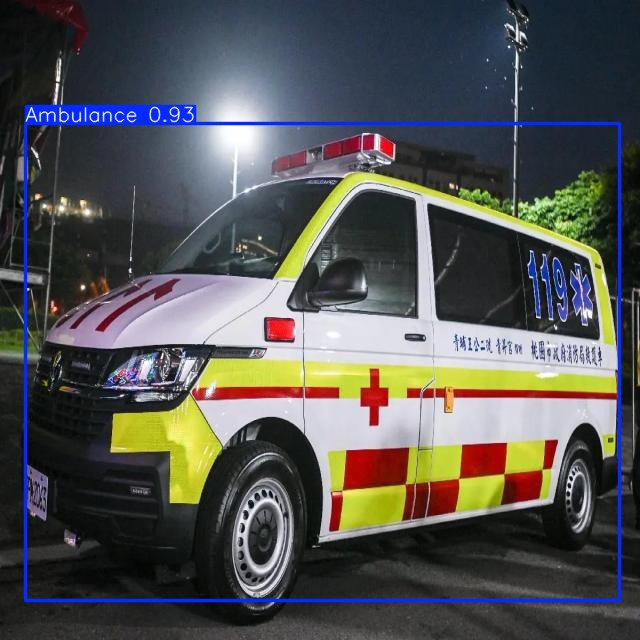

In [ ]:
from IPython.display import Image, display

display(Image('/content/runs/detect/predict/taoyuan_202305200008_webp.rf.9beb943e80029300392a4e0f327b3802.jpg'))

In [ ]:
!pip install ultralytics gradio opencv-python pillow -q
from google.colab import drive
drive.mount('/content/drive')
print("✅ Ready!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Ready!


In [ ]:
import gradio as gr, cv2, numpy as np, base64, io, time
from ultralytics import YOLO
from PIL import Image
from datetime import datetime

# ── Load model — disable augment for speed ────────────
model = YOLO("/content/drive/MyDrive/emergency_best.pt")
model.overrides["verbose"] = False

# ── Warmup model (fixes first-frame lag) ─────────────
import torch
dummy = torch.zeros(1,3,320,320)
print("Warming up model...")
for _ in range(3):
    model(np.zeros((320,320,3),dtype=np.uint8),
          verbose=False)
print("✅ Model ready! Classes:", model.names)

EMERGENCY_IDS = {0, 1, 2}
COLORS  = {
    0: (50,  50, 255),
    1: (0,  140, 255),
    2: (50,  50, 255),
    3: (80, 200,  80),
}
LABELS  = {
    0: "AMBULANCE",
    1: "FIRE TRUCK",
    2: "EMERGENCY",
    3: "VEHICLE",
}
SIGNALS = {
    "emergency": {
        "NORTH":("GREEN", 0),"SOUTH":("GREEN", 0),
        "EAST": ("RED",  30),"WEST": ("RED",  30),
    },
    "default": {
        "NORTH":("RED",  30),"SOUTH":("RED",  30),
        "EAST": ("GREEN", 0),"WEST": ("GREEN", 0),
    },
}
S = {
    "frames":0,"emergency":0,
    "fps":0.0,"last_t":time.time(),"start":time.time(),
    "signals":SIGNALS["default"].copy(),
    "snaps":[],"log":[],"counts":{0:0,1:0,2:0,3:0},
    "fps_history":[],
}

def detect(frame):
    S["frames"] += 1
    now   = time.time()
    elapsed = max(now - S["last_t"], 0.001)
    S["fps"] = 0.6*S["fps"] + 0.4*(1.0/elapsed)
    S["last_t"] = now

    # ── Resize for speed (smaller = faster FPS) ───────
    h0, w0 = frame.shape[:2]
    scale   = 480 / max(h0, w0)
    rw, rh  = int(w0*scale), int(h0*scale)
    small   = cv2.resize(frame,(rw,rh))

    # ── Run YOLO on smaller frame ─────────────────────
    results = model(
        small,
        conf=0.20,       # lower = more detections
        iou=0.40,
        imgsz=480,       # faster than 640
        augment=False,   # OFF for speed
        verbose=False,
        half=True,       # FP16 = 2x faster on GPU
    )

    found = []

    for box in results[0].boxes:
        cid       = int(box.cls[0])
        conf      = float(box.conf[0])

        # Scale box back to original frame size
        x1,y1,x2,y2 = box.xyxy[0].cpu().numpy()
        x1 = int(x1 / scale)
        y1 = int(y1 / scale)
        x2 = int(x2 / scale)
        y2 = int(y2 / scale)

        col = COLORS.get(cid,(120,120,120))
        lbl = LABELS.get(cid,"unknown")
        S["counts"][cid] = S["counts"].get(cid,0)+1

        # ── Draw thick bounding box ───────────────────
        thickness = 3 if cid in EMERGENCY_IDS else 2
        cv2.rectangle(frame,(x1,y1),(x2,y2),col,thickness)

        # ── White outline for visibility ──────────────
        if cid in EMERGENCY_IDS:
            cv2.rectangle(frame,
                (x1-2,y1-2),(x2+2,y2+2),
                (255,255,255),1)

        # ── Label background + text ───────────────────
        txt = f"{lbl} {conf:.0%}"
        fs  = 0.65
        (tw,th),_ = cv2.getTextSize(
            txt,cv2.FONT_HERSHEY_SIMPLEX,fs,2)
        cv2.rectangle(frame,
            (x1,y1-th-14),(x1+tw+10,y1),col,-1)
        cv2.putText(frame,txt,(x1+5,y1-5),
            cv2.FONT_HERSHEY_SIMPLEX,fs,(255,255,255),2)

        if cid in EMERGENCY_IDS:
            found.append((lbl,conf,(x1,y1,x2,y2)))

    # ── Emergency actions ─────────────────────────────
    if found:
        S["signals"]   = SIGNALS["emergency"].copy()
        S["emergency"] += len(found)

        # Red border flash
        cv2.rectangle(frame,(0,0),
            (frame.shape[1]-1,frame.shape[0]-1),
            (0,0,255),5)

        # Alert banner
        cv2.rectangle(frame,(0,0),
            (frame.shape[1],48),(0,0,180),-1)
        cv2.putText(frame,
            f"!!! {found[0][0]} DETECTED"
            f" — {found[0][1]:.0%} !!!",
            (10,33),cv2.FONT_HERSHEY_SIMPLEX,
            0.9,(255,255,255),2)

        for lbl,conf,box in found:
            crop = frame[
                max(0,box[1]-10):box[3]+10,
                max(0,box[0]-10):box[2]+10].copy()
            if crop.size > 0:
                rgb = cv2.cvtColor(
                    crop,cv2.COLOR_BGR2RGB)
                S["snaps"].append({
                    "img":rgb,"label":lbl,"conf":conf,
                    "time":datetime.now().strftime(
                        "%I:%M:%S %p"),
                    "msg":f"{lbl} — corridor cleared"})
                if len(S["snaps"])>9:
                    S["snaps"].pop(0)
            S["log"].insert(0,{
                "label":lbl,"conf":conf,
                "time":datetime.now().strftime(
                    "%H:%M:%S")})
            if len(S["log"])>20: S["log"].pop()
    else:
        S["signals"] = SIGNALS["default"].copy()

    # ── FPS overlay on frame ──────────────────────────
    cv2.rectangle(frame,
        (frame.shape[1]-120,0),
        (frame.shape[1],28),(0,0,0),-1)
    cv2.putText(frame,
        f"FPS: {S['fps']:.1f}",
        (frame.shape[1]-115,20),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.65,(0,255,100),2)

    return frame, found


def navbar():
    up=int(time.time()-S["start"])
    h,m,sc=up//3600,(up%3600)//60,up%60
    return f"""
    <div style='display:flex;align-items:center;
                justify-content:space-between;
                padding:10px 20px;background:#0a0a1a;
                border-bottom:1px solid #ffffff12;
                margin-bottom:8px;'>
      <div style='display:flex;align-items:center;gap:12px;'>
        <div style='width:9px;height:9px;border-radius:50%;
                    background:#3b82f6;'></div>
        <div>
          <div style='color:#fff;font-size:16px;
                      font-weight:600;'>
            AI Traffic Control System</div>
          <div style='color:#444;font-size:10px;'>
            YOLOv8 · Emergency Detection ·
            Adaptive Signal Control</div>
        </div>
        <div style='background:#ef444422;
                    border:1px solid #ef444444;
                    padding:3px 12px;border-radius:6px;
                    margin-left:8px;'>
          <span style='color:#ef4444;font-size:11px;'>
            ⚠ Incident Feed</span>
        </div>
      </div>
      <div style='display:flex;gap:20px;align-items:center;'>
        <div style='text-align:center;'>
          <div style='color:#444;font-size:9px;'>FPS</div>
          <div style='color:#22c55e;font-weight:700;
                      font-size:16px;'>
            {S["fps"]:.1f}</div>
        </div>
        <div style='text-align:center;'>
          <div style='color:#444;font-size:9px;'>
            EMERGENCY</div>
          <div style='color:#ef4444;font-weight:700;
                      font-size:16px;'>
            {S["emergency"]}</div>
        </div>
        <div style='text-align:center;'>
          <div style='color:#444;font-size:9px;'>FRAMES</div>
          <div style='color:#fff;font-weight:700;
                      font-size:16px;'>
            {S["frames"]}</div>
        </div>
        <div style='text-align:center;'>
          <div style='color:#444;font-size:9px;'>UPTIME</div>
          <div style='color:#3b82f6;font-weight:700;
                      font-size:16px;'>
            {h:02d}:{m:02d}:{sc:02d}</div>
        </div>
        <div style='background:#22c55e22;
                    border:1px solid #22c55e55;
                    padding:4px 14px;border-radius:6px;'>
          <span style='color:#22c55e;font-size:12px;
                       font-weight:600;'>● LIVE</span>
        </div>
      </div>
    </div>"""


def sidebar():
    cards=""
    for d,(st,w) in S["signals"].items():
        c = "#22c55e" if st=="GREEN" else "#ef4444"
        wt= f"{w}s"  if w>0        else "CLEAR"
        cards+=f"""
        <div style='background:#12122a;border-radius:10px;
                    padding:10px;margin-bottom:8px;
                    display:flex;align-items:center;
                    justify-content:space-between;
                    border:1px solid {c}22;'>
          <div style='display:flex;align-items:center;
                      gap:10px;'>
            <div style='width:36px;height:36px;
                        border-radius:50%;
                        background:{c}22;
                        border:2px solid {c};
                        display:flex;align-items:center;
                        justify-content:center;
                        font-weight:700;color:{c};
                        font-size:13px;'>
              {d[0]}</div>
            <div>
              <div style='color:#555;font-size:10px;'>
                {d}</div>
              <div style='color:{c};font-weight:700;
                          font-size:15px;'>{st}</div>
            </div>
          </div>
          <div style='text-align:right;'>
            <div style='color:#444;font-size:9px;'>WAIT</div>
            <div style='color:#fff;font-weight:700;
                        font-size:15px;'>{wt}</div>
          </div>
        </div>"""

    log_rows=""
    for i in S["log"][:6]:
        c=("#ef4444" if "AMBUL" in i["label"] else
           "#f97316" if "FIRE"  in i["label"] else
           "#3b82f6")
        log_rows+=f"""
        <div style='display:flex;gap:8px;padding:5px 0;
                    border-bottom:1px solid #ffffff08;
                    align-items:center;'>
          <div style='width:6px;height:6px;
                      border-radius:50%;
                      background:{c};
                      flex-shrink:0;'></div>
          <span style='color:{c};font-size:11px;
                       min-width:80px;'>
            {i["label"]}</span>
          <span style='color:#444;font-size:11px;'>
            {i["time"]}</span>
          <span style='color:#333;font-size:11px;
                       margin-left:auto;'>
            {i["conf"]:.0%}</span>
        </div>"""

    ec=S["counts"]
    return f"""
    <div style='background:#0d0d1a;padding:14px;
                border-radius:12px;
                border:1px solid #ffffff0a;'>
      <div style='color:#555;font-size:10px;
                  letter-spacing:2px;margin-bottom:10px;'>
        SIGNAL CONTROL</div>
      {cards}
    </div>
    <div style='background:#0d0d1a;padding:14px;
                border-radius:12px;
                border:1px solid #ffffff0a;
                margin-top:10px;'>
      <div style='color:#555;font-size:10px;
                  letter-spacing:2px;margin-bottom:10px;'>
        DETECTION STATS</div>
      <div style='display:grid;
                  grid-template-columns:1fr 1fr;gap:8px;'>
        <div style='background:#1a0808;
                    border:1px solid #ef444433;
                    padding:10px;border-radius:8px;'>
          <div style='color:#ef4444;font-size:11px;'>
            Ambulance</div>
          <div style='color:#fff;font-size:22px;
                      font-weight:700;'>
            {ec.get(0,0)}</div>
        </div>
        <div style='background:#1a0800;
                    border:1px solid #f9731633;
                    padding:10px;border-radius:8px;'>
          <div style='color:#f97316;font-size:11px;'>
            Fire Truck</div>
          <div style='color:#fff;font-size:22px;
                      font-weight:700;'>
            {ec.get(1,0)}</div>
        </div>
        <div style='background:#08081a;
                    border:1px solid #3b82f633;
                    padding:10px;border-radius:8px;'>
          <div style='color:#3b82f6;font-size:11px;'>
            Emergency</div>
          <div style='color:#fff;font-size:22px;
                      font-weight:700;'>
            {ec.get(2,0)}</div>
        </div>
        <div style='background:#0a1a0a;
                    border:1px solid #22c55e33;
                    padding:10px;border-radius:8px;'>
          <div style='color:#22c55e;font-size:11px;'>
            Vehicles</div>
          <div style='color:#fff;font-size:22px;
                      font-weight:700;'>
            {ec.get(3,0)}</div>
        </div>
      </div>
    </div>
    <div style='background:#0d0d1a;padding:14px;
                border-radius:12px;
                border:1px solid #ffffff0a;
                margin-top:10px;'>
      <div style='color:#555;font-size:10px;
                  letter-spacing:2px;margin-bottom:10px;'>
        INCIDENT LOG</div>
      {log_rows if log_rows else
       "<div style='color:#333;font-size:12px;'>"
       "No incidents yet</div>"}
    </div>"""


def incident_grid():
    if not S["snaps"]:
        return """
        <div style='background:#0d0d1a;padding:20px;
                    border-radius:12px;
                    border:1px solid #ffffff0a;
                    margin-bottom:10px;'>
          <div style='display:flex;align-items:center;
                      gap:8px;margin-bottom:10px;'>
            <div style='width:8px;height:8px;
                        border-radius:50%;
                        background:#ef4444;'></div>
            <span style='color:#fff;font-size:14px;
                         font-weight:500;'>
              Live Security Feed</span>
            <span style='color:#555;font-size:12px;
                         margin-left:auto;'>
              Waiting for detections...</span>
          </div>
          <div style='color:#2a2a3a;text-align:center;
                      padding:30px 0;
                      border:1px dashed #ffffff08;
                      border-radius:8px;'>
            Emergency vehicle snapshots appear here
          </div>
        </div>"""

    items=""
    for s in S["snaps"][-9:][::-1]:
        vc=("#ef4444" if "AMBUL" in s["label"] else
            "#f97316" if "FIRE"  in s["label"] else
            "#3b82f6")
        pil=Image.fromarray(s["img"]).resize((280,160))
        buf=io.BytesIO()
        pil.save(buf,format="JPEG",quality=75)
        b64=base64.b64encode(buf.getvalue()).decode()
        items+=f"""
        <div style='background:#12122a;
                    border:1px solid {vc}22;
                    border-radius:10px;overflow:hidden;'>
          <div style='position:relative;'>
            <img src='data:image/jpeg;base64,{b64}'
                 style='width:100%;height:140px;
                        object-fit:cover;display:block;'/>
            <div style='position:absolute;top:6px;right:6px;
                        background:{vc}33;
                        border:1px solid {vc}88;
                        color:{vc};padding:2px 8px;
                        border-radius:4px;font-size:11px;
                        font-weight:700;'>
              ● {s["label"]}</div>
            <div style='position:absolute;bottom:6px;
                        right:6px;color:#fff;
                        font-size:10px;font-weight:600;'>
              {s["conf"]:.0%}</div>
          </div>
          <div style='padding:8px 10px;'>
            <div style='color:#444;font-size:10px;'>
              {s["time"]}</div>
            <div style='color:#bbb;font-size:12px;
                        margin-top:2px;'>
              {s["msg"]}</div>
          </div>
        </div>"""

    return f"""
    <div style='background:#0d0d1a;padding:16px;
                border-radius:12px;
                border:1px solid #ffffff0a;
                margin-bottom:10px;'>
      <div style='display:flex;justify-content:space-between;
                  align-items:center;margin-bottom:14px;'>
        <div style='display:flex;align-items:center;gap:8px;'>
          <div style='width:8px;height:8px;border-radius:50%;
                      background:#ef4444;'></div>
          <span style='color:#fff;font-size:14px;
                       font-weight:500;'>
            Live Security Feed</span>
        </div>
        <span style='color:#ef4444;font-size:12px;'>
          Tracking {len(S["snaps"])} Anomalies</span>
      </div>
      <div style='display:grid;
                  grid-template-columns:repeat(3,1fr);
                  gap:10px;'>
        {items}
      </div>
    </div>"""


def process(image):
    if image is None or not isinstance(image,np.ndarray):
        blank=np.zeros((480,640,3),dtype=np.uint8)
        cv2.putText(blank,"Click camera icon to begin",
            (100,240),cv2.FONT_HERSHEY_SIMPLEX,
            0.8,(50,50,50),2)
        return (Image.fromarray(blank),
                navbar(),incident_grid(),sidebar())

    # Resize input for speed
    frame = cv2.cvtColor(image,cv2.COLOR_RGB2BGR)
    frame = cv2.resize(frame,(640,480))

    ann,_ = detect(frame.copy())
    rgb   = cv2.cvtColor(ann,cv2.COLOR_BGR2RGB)
    return (Image.fromarray(rgb),
            navbar(),incident_grid(),sidebar())


css="""
body,.gradio-container{
  background:#080818!important;
  color:#fff!important;
  font-family:'Segoe UI',sans-serif!important;
}
.gradio-container{
  max-width:100%!important;
  padding:0!important;
}
footer{display:none!important;}
"""

with gr.Blocks(css=css,title="AI Traffic Control",
               theme=gr.themes.Base()) as demo:
    nav =gr.HTML(navbar())
    with gr.Row():
        with gr.Column(scale=3):
            grid   =gr.HTML(incident_grid())
            gr.HTML(
                "<div style='color:#666;font-size:11px;"
                "margin:6px 0 4px;'>● LIVE CAMERA</div>")
            cam_in =gr.Image(
                sources=["webcam"],
                streaming=True,
                label="",
                show_label=False,
                height=380,
                mirror_webcam=False)
            cam_out=gr.Image(
                label="Detected Output",
                show_label=True,
                height=380)
        with gr.Column(scale=1):
            side=gr.HTML(sidebar())

    cam_in.stream(
        fn=process,
        inputs=[cam_in],
        outputs=[cam_out,nav,grid,side],
        time_limit=3600,
        stream_every=0.1)   # 0.1 = 10 FPS max

demo.launch(share=True)

Warming up model...
✅ Model ready! Classes: {0: 'Ambulance', 1: 'fire truck', 2: 'police'}


/tmp/ipykernel_2779/1251036954.py:483: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(css=css,title="AI Traffic Control",
/tmp/ipykernel_2779/1251036954.py:483: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=css,title="AI Traffic Control",


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://694e9ed8432bc54898.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
from ultralytics import YOLO
model = YOLO("/content/drive/MyDrive/emergency_best.pt")
print("Classes:", model.names)

Classes: {0: 'Ambulance', 1: 'fire truck', 2: 'police'}


In [ ]:
import gradio as gr, cv2, numpy as np, base64, io, time
from ultralytics import YOLO
from PIL import Image
from datetime import datetime

model = YOLO("/content/drive/MyDrive/emergency_best.pt")
model.overrides["verbose"] = False

print("Warming up...")
for _ in range(3):
    model(np.zeros((320,320,3),dtype=np.uint8),verbose=False)
print("✅ Classes:", model.names)
# {0:'Ambulance', 1:'fire truck', 2:'police'}

# ── Correct labels & colors ───────────────────────────
LABELS = {0:"AMBULANCE", 1:"FIRE TRUCK", 2:"POLICE"}
COLORS = {
    0: (50,  50, 255),   # Ambulance  = Red
    1: (0,  140, 255),   # Fire Truck = Orange
    2: (255, 80,  80),   # Police     = Blue
}
EMERGENCY_IDS = {0, 1, 2}  # all 3 are emergency

# ── Per-vehicle signal logic ──────────────────────────
SIGNAL_PER_TYPE = {
    "AMBULANCE": {
        "NORTH":("GREEN", 0), "SOUTH":("GREEN", 0),
        "EAST": ("RED",  35), "WEST": ("RED",  35),
    },
    "FIRE TRUCK": {
        "NORTH":("GREEN", 0), "SOUTH":("GREEN", 0),
        "EAST": ("RED",  45), "WEST": ("RED",  45),
    },
    "POLICE": {
        "NORTH":("GREEN", 0), "SOUTH":("HOLD", 15),
        "EAST": ("RED",  20), "WEST": ("RED",  20),
    },
}
DEFAULT_SIGNALS = {
    "NORTH":("RED",  30), "SOUTH":("RED",  30),
    "EAST": ("GREEN", 0), "WEST": ("GREEN", 0),
}
PRIORITY = {"AMBULANCE":3, "FIRE TRUCK":2, "POLICE":1}

# ── IP Webcam setup ───────────────────────────────────
# Install IP Webcam on Android → Start server → enter IP
IP_URL  = "http://YOUR_PHONE_IP:8080/video"
ip_cap  = cv2.VideoCapture(IP_URL)
ip_cap.set(cv2.CAP_PROP_BUFFERSIZE, 1)
USE_IP  = ip_cap.isOpened()
print("IP Webcam:", "✅ Connected!" if USE_IP
      else "❌ Not found — using browser cam")

# ── State ─────────────────────────────────────────────
S = {
    "frames":0, "emergency":0,
    "fps":0.0,  "last_t":time.time(),
    "start":time.time(),
    "signals":DEFAULT_SIGNALS.copy(),
    "snaps":[], "log":[],
    "counts":{"AMBULANCE":0,"FIRE TRUCK":0,"POLICE":0},
    "last_vehicle": "NONE",
}


def detect(frame):
    S["frames"] += 1
    now     = time.time()
    elapsed = max(now - S["last_t"], 0.001)
    S["fps"]    = 0.6*S["fps"] + 0.4*(1.0/elapsed)
    S["last_t"] = now

    # Resize for speed
    h0,w0   = frame.shape[:2]
    scale   = 480 / max(h0,w0)
    small   = cv2.resize(frame,(int(w0*scale),int(h0*scale)))

    results = model(small, conf=0.20, iou=0.40,
                    imgsz=480, augment=False,
                    half=True, verbose=False)
    found   = []

    for box in results[0].boxes:
        cid        = int(box.cls[0])
        conf       = float(box.conf[0])
        x1,y1,x2,y2 = box.xyxy[0].cpu().numpy()

        # Scale back to original
        x1,y1,x2,y2 = (int(x1/scale), int(y1/scale),
                        int(x2/scale), int(y2/scale))

        col = COLORS[cid]
        lbl = LABELS[cid]
        S["counts"][lbl] = S["counts"].get(lbl,0) + 1

        # ── Double border for visibility ──────────────
        cv2.rectangle(frame,
            (x1-3,y1-3),(x2+3,y2+3),(255,255,255),1)
        cv2.rectangle(frame,
            (x1,y1),(x2,y2),col,3)

        # ── Bold label ────────────────────────────────
        txt = f"{lbl}  {conf:.0%}"
        fs  = 0.7
        (tw,th),_ = cv2.getTextSize(
            txt,cv2.FONT_HERSHEY_SIMPLEX,fs,2)
        cv2.rectangle(frame,
            (x1,y1-th-16),(x1+tw+12,y1),col,-1)
        cv2.rectangle(frame,
            (x1,y1-th-16),(x1+tw+12,y1),(255,255,255),1)
        cv2.putText(frame,txt,(x1+6,y1-6),
            cv2.FONT_HERSHEY_SIMPLEX,fs,(255,255,255),2)

        found.append((lbl,conf,(x1,y1,x2,y2)))

    # ── Signals per vehicle type ──────────────────────
    if found:
        top = max(found,
                  key=lambda x: PRIORITY.get(x[0],0))
        top_label = top[0]
        S["signals"]      = SIGNAL_PER_TYPE[top_label].copy()
        S["last_vehicle"] = top_label
        S["emergency"]   += len(found)

        # Flash border color per vehicle
        border_col = COLORS[
            list(LABELS.keys())[
                list(LABELS.values()).index(top_label)]]
        cv2.rectangle(frame,(0,0),
            (frame.shape[1]-1,frame.shape[0]-1),
            border_col,5)

        # Alert banner
        cv2.rectangle(frame,(0,0),
            (frame.shape[1],50),
            tuple(int(c*0.6) for c in border_col),-1)
        cv2.putText(frame,
            f"!!! {top_label} DETECTED"
            f" — {top[1]:.0%} !!!",
            (10,34),cv2.FONT_HERSHEY_SIMPLEX,
            0.9,(255,255,255),2)

        for lbl,conf,box in found:
            crop = frame[
                max(0,box[1]-10):box[3]+10,
                max(0,box[0]-10):box[2]+10].copy()
            if crop.size > 0:
                S["snaps"].append({
                    "img": cv2.cvtColor(
                        crop,cv2.COLOR_BGR2RGB),
                    "label":lbl,"conf":conf,
                    "time": datetime.now().strftime(
                        "%I:%M:%S %p"),
                    "msg":  {
                        "AMBULANCE":
                            "Ambulance — corridor cleared",
                        "FIRE TRUCK":
                            "Fire Truck — full clear",
                        "POLICE":
                            "Police — priority signal",
                    }.get(lbl,"Emergency detected")
                })
                if len(S["snaps"])>9: S["snaps"].pop(0)
            S["log"].insert(0,{
                "label":lbl,"conf":conf,
                "time": datetime.now().strftime("%H:%M:%S"),
                "vehicle": lbl,
            })
            if len(S["log"])>20: S["log"].pop()
    else:
        S["signals"]      = DEFAULT_SIGNALS.copy()
        S["last_vehicle"] = "NONE"

    # FPS overlay
    cv2.rectangle(frame,
        (frame.shape[1]-130,0),
        (frame.shape[1],30),(0,0,0),-1)
    cv2.putText(frame,f"FPS: {S['fps']:.1f}",
        (frame.shape[1]-125,22),
        cv2.FONT_HERSHEY_SIMPLEX,0.7,(0,255,100),2)

    return frame, found


def navbar():
    up  = int(time.time()-S["start"])
    h,m,sc = up//3600,(up%3600)//60,up%60
    vc  = S["last_vehicle"]
    v_color = ("#ef4444" if vc=="AMBULANCE" else
               "#f97316" if vc=="FIRE TRUCK" else
               "#3b82f6" if vc=="POLICE"     else "#444")
    return f"""
    <div style='display:flex;align-items:center;
                justify-content:space-between;
                padding:10px 20px;background:#0a0a1a;
                border-bottom:1px solid #ffffff12;
                margin-bottom:8px;'>
      <div style='display:flex;align-items:center;gap:12px;'>
        <div style='width:9px;height:9px;border-radius:50%;
                    background:#3b82f6;'></div>
        <div>
          <div style='color:#fff;font-size:16px;
                      font-weight:600;'>
            AI Traffic Control System</div>
          <div style='color:#444;font-size:10px;'>
            YOLOv8 · Ambulance · Fire Truck · Police</div>
        </div>
        <div style='background:{v_color}22;
                    border:1px solid {v_color}55;
                    padding:3px 12px;border-radius:6px;
                    margin-left:8px;'>
          <span style='color:{v_color};font-size:11px;
                       font-weight:600;'>
            {"⚠ " + vc if vc != "NONE"
             else "● MONITORING"}</span>
        </div>
      </div>
      <div style='display:flex;gap:20px;align-items:center;'>
        <div style='text-align:center;'>
          <div style='color:#444;font-size:9px;'>FPS</div>
          <div style='color:#22c55e;font-weight:700;
                      font-size:16px;'>
            {S["fps"]:.1f}</div>
        </div>
        <div style='text-align:center;'>
          <div style='color:#444;font-size:9px;'>
            EMERGENCY</div>
          <div style='color:#ef4444;font-weight:700;
                      font-size:16px;'>
            {S["emergency"]}</div>
        </div>
        <div style='text-align:center;'>
          <div style='color:#444;font-size:9px;'>FRAMES</div>
          <div style='color:#fff;font-weight:700;
                      font-size:16px;'>
            {S["frames"]}</div>
        </div>
        <div style='text-align:center;'>
          <div style='color:#444;font-size:9px;'>UPTIME</div>
          <div style='color:#3b82f6;font-weight:700;
                      font-size:16px;'>
            {h:02d}:{m:02d}:{sc:02d}</div>
        </div>
        <div style='background:#22c55e22;
                    border:1px solid #22c55e55;
                    padding:4px 14px;border-radius:6px;'>
          <span style='color:#22c55e;font-size:12px;
                       font-weight:600;'>● LIVE</span>
        </div>
      </div>
    </div>"""


def sidebar():
    cards = ""
    for d,(st,w) in S["signals"].items():
        c  = ("#22c55e" if st=="GREEN" else
              "#eab308" if st=="HOLD"  else "#ef4444")
        wt = f"{w}s" if w>0 else "CLEAR"
        arrow = {"NORTH":"↑","SOUTH":"↓",
                 "EAST":"→","WEST":"←"}.get(d,"●")
        cards += f"""
        <div style='background:#12122a;border-radius:10px;
                    padding:10px 12px;margin-bottom:8px;
                    display:flex;align-items:center;
                    justify-content:space-between;
                    border:1px solid {c}33;'>
          <div style='display:flex;align-items:center;
                      gap:10px;'>
            <div style='width:38px;height:38px;
                        border-radius:50%;
                        background:{c}22;
                        border:2px solid {c};
                        display:flex;align-items:center;
                        justify-content:center;
                        font-weight:700;color:{c};
                        font-size:16px;'>
              {arrow}</div>
            <div>
              <div style='color:#555;font-size:10px;
                          letter-spacing:1px;'>{d}</div>
              <div style='color:{c};font-weight:700;
                          font-size:16px;'>{st}</div>
            </div>
          </div>
          <div style='text-align:right;'>
            <div style='color:#444;font-size:9px;'>WAIT</div>
            <div style='color:#fff;font-weight:700;
                        font-size:16px;'>{wt}</div>
          </div>
        </div>"""

    # Detection stats with correct labels
    c  = S["counts"]
    lv = S["last_vehicle"]
    log_rows = ""
    for i in S["log"][:6]:
        vc = ("#ef4444" if i["vehicle"]=="AMBULANCE"  else
              "#f97316" if i["vehicle"]=="FIRE TRUCK"  else
              "#3b82f6")
        log_rows += f"""
        <div style='display:flex;gap:8px;padding:5px 0;
                    border-bottom:1px solid #ffffff08;
                    align-items:center;'>
          <div style='width:6px;height:6px;
                      border-radius:50%;background:{vc};
                      flex-shrink:0;'></div>
          <span style='color:{vc};font-size:11px;
                       min-width:85px;font-weight:600;'>
            {i["vehicle"]}</span>
          <span style='color:#444;font-size:11px;'>
            {i["time"]}</span>
          <span style='color:#555;font-size:11px;
                       margin-left:auto;'>
            {i["conf"]:.0%}</span>
        </div>"""

    return f"""
    <div style='background:#0d0d1a;padding:14px;
                border-radius:12px;
                border:1px solid #ffffff0a;'>
      <div style='color:#555;font-size:10px;
                  letter-spacing:2px;margin-bottom:10px;'>
        ◉ SIGNAL CONTROL</div>
      {cards}
    </div>
    <div style='background:#0d0d1a;padding:14px;
                border-radius:12px;
                border:1px solid #ffffff0a;
                margin-top:10px;'>
      <div style='color:#555;font-size:10px;
                  letter-spacing:2px;margin-bottom:10px;'>
        ◉ DETECTION STATS</div>
      <div style='display:grid;
                  grid-template-columns:1fr 1fr 1fr;
                  gap:8px;'>
        <div style='background:#1a0808;
                    border:1px solid #ef444455;
                    padding:10px;border-radius:8px;
                    text-align:center;'>
          <div style='color:#ef4444;font-size:10px;
                      letter-spacing:1px;'>AMBULANCE</div>
          <div style='color:#fff;font-size:24px;
                      font-weight:700;'>
            {c.get("AMBULANCE",0)}</div>
        </div>
        <div style='background:#1a0800;
                    border:1px solid #f9731655;
                    padding:10px;border-radius:8px;
                    text-align:center;'>
          <div style='color:#f97316;font-size:10px;
                      letter-spacing:1px;'>FIRE TRUCK</div>
          <div style='color:#fff;font-size:24px;
                      font-weight:700;'>
            {c.get("FIRE TRUCK",0)}</div>
        </div>
        <div style='background:#08081a;
                    border:1px solid #3b82f655;
                    padding:10px;border-radius:8px;
                    text-align:center;'>
          <div style='color:#3b82f6;font-size:10px;
                      letter-spacing:1px;'>POLICE</div>
          <div style='color:#fff;font-size:24px;
                      font-weight:700;'>
            {c.get("POLICE",0)}</div>
        </div>
      </div>
    </div>
    <div style='background:#0d0d1a;padding:14px;
                border-radius:12px;
                border:1px solid #ffffff0a;
                margin-top:10px;'>
      <div style='color:#555;font-size:10px;
                  letter-spacing:2px;margin-bottom:10px;'>
        ◉ INCIDENT LOG</div>
      {log_rows if log_rows else
       "<div style='color:#333;font-size:12px;'>"
       "No incidents yet</div>"}
    </div>"""


def incident_grid():
    if not S["snaps"]:
        return """
        <div style='background:#0d0d1a;padding:20px;
                    border-radius:12px;
                    border:1px solid #ffffff0a;
                    margin-bottom:10px;'>
          <div style='display:flex;align-items:center;
                      gap:8px;margin-bottom:10px;'>
            <div style='width:8px;height:8px;
                        border-radius:50%;
                        background:#ef4444;'></div>
            <span style='color:#fff;font-size:14px;
                         font-weight:500;'>
              Live Security Feed</span>
            <span style='color:#555;font-size:12px;
                         margin-left:auto;'>
              Waiting for detections...</span>
          </div>
          <div style='color:#2a2a3a;text-align:center;
                      padding:30px 0;
                      border:1px dashed #ffffff08;
                      border-radius:8px;font-size:13px;'>
            Ambulance · Fire Truck · Police snapshots
            appear here
          </div>
        </div>"""

    items = ""
    for s in S["snaps"][-9:][::-1]:
        vc = ("#ef4444" if s["label"]=="AMBULANCE"  else
              "#f97316" if s["label"]=="FIRE TRUCK"  else
              "#3b82f6")
        pil = Image.fromarray(s["img"]).resize((280,160))
        buf = io.BytesIO()
        pil.save(buf,format="JPEG",quality=80)
        b64 = base64.b64encode(buf.getvalue()).decode()
        items += f"""
        <div style='background:#12122a;
                    border:1px solid {vc}33;
                    border-radius:10px;overflow:hidden;'>
          <div style='position:relative;'>
            <img src='data:image/jpeg;base64,{b64}'
                 style='width:100%;height:140px;
                        object-fit:cover;display:block;'/>
            <div style='position:absolute;top:6px;
                        right:6px;background:{vc}44;
                        border:1px solid {vc};
                        color:{vc};padding:2px 10px;
                        border-radius:4px;font-size:11px;
                        font-weight:700;'>
              ● {s["label"]}</div>
            <div style='position:absolute;bottom:6px;
                        right:6px;color:#fff;
                        font-size:11px;font-weight:600;
                        background:#00000088;
                        padding:1px 6px;border-radius:3px;'>
              {s["conf"]:.0%}</div>
          </div>
          <div style='padding:8px 10px;'>
            <div style='color:#444;font-size:10px;'>
              {s["time"]}</div>
            <div style='color:#bbb;font-size:12px;
                        margin-top:2px;'>
              {s["msg"]}</div>
          </div>
        </div>"""

    return f"""
    <div style='background:#0d0d1a;padding:16px;
                border-radius:12px;
                border:1px solid #ffffff0a;
                margin-bottom:10px;'>
      <div style='display:flex;justify-content:space-between;
                  align-items:center;margin-bottom:14px;'>
        <div style='display:flex;align-items:center;gap:8px;'>
          <div style='width:8px;height:8px;border-radius:50%;
                      background:#ef4444;'></div>
          <span style='color:#fff;font-size:14px;
                       font-weight:500;'>
            Live Security Feed</span>
        </div>
        <span style='color:#ef4444;font-size:12px;'>
          Tracking {len(S["snaps"])} Anomalies</span>
      </div>
      <div style='display:grid;
                  grid-template-columns:repeat(3,1fr);
                  gap:10px;'>
        {items}
      </div>
    </div>"""


def process(image):
    if image is None or not isinstance(image,np.ndarray):
        blank=np.zeros((480,640,3),dtype=np.uint8)
        cv2.putText(blank,"Click camera icon to begin",
            (100,240),cv2.FONT_HERSHEY_SIMPLEX,
            0.8,(50,50,50),2)
        return (Image.fromarray(blank),
                navbar(),incident_grid(),sidebar())

    # Resize input for speed
    frame = cv2.cvtColor(image,cv2.COLOR_RGB2BGR)
    frame = cv2.resize(frame,(640,480))

    ann,_ = detect(frame.copy())
    rgb   = cv2.cvtColor(ann,cv2.COLOR_BGR2RGB)
    return (Image.fromarray(rgb),
            navbar(),incident_grid(),sidebar())


css="""
body,.gradio-container{
  background:#080818!important;
  color:#fff!important;
  font-family:'Segoe UI',sans-serif!important;
}
.gradio-container{max-width:100%!important;padding:0!important;}
footer{display:none!important;}
"""

with gr.Blocks(css=css,title="AI Traffic Control",
               theme=gr.themes.Base()) as demo:
    nav =gr.HTML(navbar())
    with gr.Row():
        with gr.Column(scale=3):
            grid   =gr.HTML(incident_grid())
            gr.HTML(
                "<div style='color:#666;font-size:11px;"
                "margin:6px 0 4px;'>● LIVE CAMERA</div>")
            cam_in =gr.Image(
                sources=["webcam"],
                streaming=True,
                label="",
                show_label=False,
                height=380,
                mirror_webcam=False)
            cam_out=gr.Image(
                label="Detected Output",
                show_label=True,
                height=380)
        with gr.Column(scale=1):
            side=gr.HTML(sidebar())

    cam_in.stream(
        fn=process,
        inputs=[cam_in],
        outputs=[cam_out,nav,grid,side],
        time_limit=3600,
        stream_every=0.1)   # 0.1 = 10 FPS max

demo.launch(share=True)

Warming up...
✅ Classes: {0: 'Ambulance', 1: 'fire truck', 2: 'police'}
IP Webcam: ❌ Not found — using browser cam


/tmp/ipykernel_2779/454018389.py:504: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(css=css,title="AI Traffic Control",
/tmp/ipykernel_2779/454018389.py:504: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=css,title="AI Traffic Control",


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://97a36acf12e6102d26.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Warming up...
✅ Classes: {0: 'Ambulance', 1: 'fire truck', 2: 'police'}
IP Webcam: ❌ Not found — using browser cam


/tmp/ipykernel_2779/454018389.py:504: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(css=css,title="AI Traffic Control",
/tmp/ipykernel_2779/454018389.py:504: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=css,title="AI Traffic Control",


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://cf0c28e539c1276f0f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
